# Gradual SN Lesion: Adaptive Reserve Moderates Modularity–Behavior Coupling

Across lesion intensities $\lambda \in [0, 1]$ (step 0.1), test whether **adaptive reserve** moderates the link between global modularity and **behavioral coupling**.

- **Model B (SN lesion):** Coupling $\sim \Delta Q^{\mathrm{SN}}_{\mathrm{auc}} \times$ Reserve, stratified by $\lambda$
- **$\beta(\lambda)$ Trajectory:** interaction term from Model B at each $\lambda$

Analysis settings: **states 3–6**, **1000 parcels**.

At $\lambda=0$, $Q^{\mathrm{intact}}_{\mathrm{auc}}$ is aligned with `global_modularity_auc` from the unified graph analysis.

Behavioral covariates are loaded from the bundled `data/rt_vars.csv`.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
from statsmodels.api import OLS, add_constant


def _resolve_package_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data" / "sn_lesion_auc_merged.csv").is_file():
            return candidate
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
        if start.name == "notebooks" and (start.parent / "data").is_dir():
            return start.parent
    raise FileNotFoundError(
        "Could not locate gradual_virtual_lesion package root "
        f"(started search from: {start})"
    )


ROOT = _resolve_package_root()
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# --- analysis config ---
STATES = (3, 6)
METHOD = "merged_all_statistical"
LESION_LAMBDAS = np.arange(0, 1.01, 0.1)
MODEL_B_LAMBDAS = LESION_LAMBDAS[LESION_LAMBDAS > 0]
LAMBDA_MIN_PLOT = 0.1
TRAJ_X_MIN = 0.1
TRAJ_X_MAX = 1.0
TRAJ_X_TICK_STEP = 0.3
DELTAQ_LAMBDAS = [0.1, 0.5, 1.0]
NULL_LAMBDAS = [0.1, 0.4, 0.7, 1.0]

COUPLING_COL = "rt_transition_diff__flexibility_stability"
RESERVE_COL = "rt_duration_diff__long-short"
X_COL_MODEL_B = "deltaQ_SN_auc"
X_COL_MODEL_RANDOM = "deltaQ_null_auc"

SN_RED = "#D55E00"
SN_RED_LIGHT = "#F5DACC"
BLUE = "#56B4E9"
BLUE_LIGHT = "#D5EEF8"
CD_GREEN = "#009B77"
CD_GREEN_LIGHT = "#D0EDE6"
NET_GRAY = "#737373"
GRAY_LIGHT = "#E8E8E8"
TEXT = "#1A1A1A"
FS = 11
FS_TICK = 11
PANEL_WIDTH = 3.2 * 1.2 * 0.9
DPI = 600
INTERACT_AXIS_LIM = 3.0
INTERACT_AXIS_TICK_STEP = 2.0
INTERACT_X_SHIFT_PT = 10
INTERACT_TICK_LEN_PT = 4
Y_LABEL_INTERACT = r"Behavioral Coordination ($RT_{\mathrm{Diff}}$; $Z$)"

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": FS,
        "axes.labelsize": FS,
        "axes.titlesize": FS,
        "xtick.labelsize": FS_TICK,
        "ytick.labelsize": FS_TICK,
        "legend.fontsize": FS,
        "axes.linewidth": 0.75,
        "figure.facecolor": "none",
        "axes.facecolor": "none",
        "savefig.facecolor": "none",
        "savefig.transparent": True,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

DATA_PATHS = {
    "sn_auc": DATA_DIR / "sn_lesion_auc_merged.csv",
    "null_auc": DATA_DIR / "null_lesion_auc_merged.csv",
    "modularity": DATA_DIR / "global_modularity_auc.csv",
    "rt_vars": DATA_DIR / "rt_vars.csv",
}

for label, path in DATA_PATHS.items():
    if not path.is_file():
        raise FileNotFoundError(f"Missing {label} data file: {path}")

print("Data files:")
for label, path in DATA_PATHS.items():
    print(f" {label}: {path.name}")


Data files:
 sn_auc: sn_lesion_auc_merged.csv
 null_auc: null_lesion_auc_merged.csv
 modularity: global_modularity_auc.csv
 rt_vars: rt_vars.csv


In [2]:
def load_inputs() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Load neuroimaging and behavior summaries.

    @returns {tuple} SN AUC, null AUC, modularity, and RT variable tables.
    """
    sn = pd.read_csv(DATA_PATHS["sn_auc"])
    null = pd.read_csv(DATA_PATHS["null_auc"])
    mod = pd.read_csv(DATA_PATHS["modularity"])
    rt = pd.read_csv(DATA_PATHS["rt_vars"])
    for df in (sn, null, mod, rt):
        df["subject"] = df["subject"].astype(str)
    if "lesion_lambda" in sn.columns:
        sn["lesion_lambda"] = sn["lesion_lambda"].astype(float).round(1)
    if "lesion_lambda" in null.columns:
        null["lesion_lambda"] = null["lesion_lambda"].astype(float).round(1)
    return sn, null, mod, rt


def prepare_merged_df(
    sn_auc_df: pd.DataFrame,
    unified_df: pd.DataFrame,
    rt_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Merge SN lesion AUC with modularity and RT-derived covariates.

    @param {pd.DataFrame} sn_auc_df - SN gradual lesion metrics by lambda.
    @param {pd.DataFrame} unified_df - Subject-level global modularity AUC.
    @param {pd.DataFrame} rt_df - Reserve and coupling metrics.
    @returns {pd.DataFrame} Analysis-ready long table for SN models.
    """
    sn = sn_auc_df.copy()
    uni = unified_df.copy()
    rt = rt_df.copy()
    behav_cols = ["subject", COUPLING_COL, RESERVE_COL]
    df = (
        sn.merge(uni, on="subject", how="inner")
        .merge(rt[behav_cols], on="subject", how="inner")
    )
    df["Q_intact_auc_aligned"] = df["global_modularity_auc"]
    df["Q_intact_auc"] = df["Q_intact_auc_aligned"]
    df["deltaQ_SN_auc"] = df["Q_intact_auc"] - df["Q_lesion_SN_auc"]
    lam0 = df[np.isclose(df["lesion_lambda"], 0.0)]
    if len(lam0):
        raw_diff = (lam0["Q_intact_auc_aligned"] - lam0["global_modularity_auc"]).abs()
        pre_align = sn[np.isclose(sn["lesion_lambda"], 0.0)].merge(uni, on="subject", how="inner")
        pre_diff = (pre_align["Q_intact_auc"] - pre_align["global_modularity_auc"]).abs()
        print(
            f"lambda=0 alignment: mean |Q_intact - global_modularity| "
            f"before={pre_diff.mean():.6f}, after={raw_diff.mean():.6f}"
        )
    return df


def prepare_merged_null_df(
    null_auc_df: pd.DataFrame,
    unified_df: pd.DataFrame,
    rt_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Merge degree-matched null lesion AUC with modularity and RT covariates.

    @param {pd.DataFrame} null_auc_df - Null gradual lesion metrics by lambda.
    @param {pd.DataFrame} unified_df - Subject-level global modularity AUC.
    @param {pd.DataFrame} rt_df - Reserve and coupling metrics.
    @returns {pd.DataFrame} Analysis-ready long table for null models.
    """
    null_df = null_auc_df.copy()
    uni = unified_df.copy()
    rt = rt_df.copy()
    behav_cols = ["subject", COUPLING_COL, RESERVE_COL]
    df = (
        null_df.merge(uni, on="subject", how="inner")
        .merge(rt[behav_cols], on="subject", how="inner")
    )
    df["Q_intact_auc"] = df["global_modularity_auc"]
    df["deltaQ_null_auc"] = df["Q_intact_auc"] - df["Q_lesion_null_auc"]
    mask0 = np.isclose(df["lesion_lambda"], 0.0)
    df.loc[mask0, "Q_lesion_null_auc"] = df.loc[mask0, "global_modularity_auc"]
    df.loc[mask0, "deltaQ_null_auc"] = 0.0
    return df


sn_auc_df, null_auc_df, unified_df, rt_df = load_inputs()
merged_df = prepare_merged_df(sn_auc_df, unified_df, rt_df)
merged_null_df = prepare_merged_null_df(null_auc_df, unified_df, rt_df)

print(f"merged SN rows: {len(merged_df)} subjects: {merged_df['subject'].nunique()}")
print(f"merged null rows: {len(merged_null_df)} subjects: {merged_null_df['subject'].nunique()}")
print(f"lambda levels: {sorted(merged_df['lesion_lambda'].unique())}")
merged_df.head()


lambda=0 alignment: mean |Q_intact - global_modularity| before=0.000000, after=0.000000
merged SN rows: 473 subjects: 43
merged null rows: 473 subjects: 43
lambda levels: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]


,subject,lesion_lambda,Q_intact_auc,Q_lesion_SN_auc,deltaQ_SN_auc,k_lesioned,k_roi_pool,global_modularity_auc,rt_transition_diff__flexibility_stability,rt_duration_diff__long-short,Q_intact_auc_aligned
0,sub-001,0.0,0.129393,0.129178,0.000215,0.0,103.0,0.129393,282.947203,90.897059,0.129393
1,sub-001,0.1,0.129393,0.131064,-0.001671,10.0,103.0,0.129393,282.947203,90.897059,0.129393
2,sub-001,0.2,0.129393,0.133969,-0.004576,21.0,103.0,0.129393,282.947203,90.897059,0.129393
3,sub-001,0.3,0.129393,0.132947,-0.003554,31.0,103.0,0.129393,282.947203,90.897059,0.129393
4,sub-001,0.4,0.129393,0.130892,-0.001500,41.0,103.0,0.129393,282.947203,90.897059,0.129393


In [3]:
def zscore_series(s: pd.Series) -> pd.Series:
    std = s.std(ddof=1)
    if not np.isfinite(std) or std == 0:
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / std


def _has_usable_variance(sub: pd.DataFrame, cols: list[str]) -> bool:
    return all(sub[c].std(ddof=1) > 0 for c in cols)


def fit_moderation_by_lambda(
    df: pd.DataFrame,
    x_col: str,
    *,
    model_label: str,
    lambdas: np.ndarray | None = None,
    min_n: int = 8,
) -> pd.DataFrame:
    """
    Fit Coupling ~ X x Reserve OLS models at each lesion_lambda.

    @param {pd.DataFrame} df - Long analysis table.
    @param {str} x_col - Predictor column (delta Q).
    @param {str} model_label - Model name for output table.
    @returns {pd.DataFrame} Coefficients and inference per lambda.
    """
    lambdas = LESION_LAMBDAS if lambdas is None else np.asarray(lambdas, dtype=float)
    rows = []
    for lam in lambdas:
        sub_lam = df[np.isclose(df["lesion_lambda"], float(lam))]
        cols = [x_col, RESERVE_COL, COUPLING_COL]
        raw = sub_lam[cols].dropna().copy()
        if len(raw) < min_n or not _has_usable_variance(raw, cols):
            rows.append(
                {
                    "model": model_label,
                    "lesion_lambda": float(lam),
                    "x_col": x_col,
                    "n": len(raw),
                    "b1": np.nan,
                    "b2": np.nan,
                    "b3": np.nan,
                    "t_b3": np.nan,
                    "df": np.nan,
                    "p_b3": np.nan,
                    "ci_lo": np.nan,
                    "ci_hi": np.nan,
                    "r2": np.nan,
                }
            )
            continue
        sub = raw.copy()
        for c in cols:
            sub[c] = zscore_series(sub[c])
        x, w, y = (sub[c].values for c in cols)
        model = OLS(y, add_constant(np.column_stack([x, w, x * w]))).fit()
        ci = np.asarray(model.conf_int())
        rows.append(
            {
                "model": model_label,
                "lesion_lambda": float(lam),
                "x_col": x_col,
                "n": len(raw),
                "b1": float(model.params[1]),
                "b2": float(model.params[2]),
                "b3": float(model.params[3]),
                "t_b3": float(model.tvalues[3]),
                "df": float(model.df_resid),
                "p_b3": float(model.pvalues[3]),
                "ci_lo": float(ci[3, 0]),
                "ci_hi": float(ci[3, 1]),
                "r2": float(model.rsquared),
            }
        )
    return pd.DataFrame(rows)


def infer_divergence_regime(
    model_sn: pd.DataFrame,
    model_random: pd.DataFrame,
    *,
    lambda_min: float = LAMBDA_MIN_PLOT,
) -> tuple[float, float]:
    """
    Highlight lambda range where SN interaction beta diverges from null track.

    @param {pd.DataFrame} model_sn - SN moderation results.
    @param {pd.DataFrame} model_random - Null moderation results.
    @returns {tuple[float, float]} Start and end lambda for shaded regime.
    """
    sn = model_sn[model_sn["lesion_lambda"] >= lambda_min - 1e-9].copy()
    rnd = model_random.set_index("lesion_lambda")
    hit: list[float] = []
    for _, row in sn.iterrows():
        lam = float(row["lesion_lambda"])
        if lam not in rnd.index or not np.isfinite(row["b3"]):
            continue
        b3_r = float(rnd.loc[lam, "b3"])
        if row["p_b3"] < 0.05 and row["b3"] > b3_r + 0.10:
            hit.append(lam)
    if hit:
        return float(min(hit)), 1.0
    return 0.4, 1.0


def fit_moderation_at_lambda(df: pd.DataFrame, lam: float, x_col: str) -> dict | None:
    """Return OLS fit dict for one lambda (interaction scatter panels)."""
    sub_lam = df[np.isclose(df["lesion_lambda"], float(lam))]
    cols = [x_col, RESERVE_COL, COUPLING_COL]
    raw = sub_lam[cols].dropna().copy()
    if len(raw) < 8 or not _has_usable_variance(raw, cols):
        return None
    sub = raw.copy()
    for c in cols:
        sub[c] = zscore_series(sub[c])
    x, w, y = (sub[c].values for c in cols)
    model = OLS(y, add_constant(np.column_stack([x, w, x * w]))).fit()
    return {"model": model, "sub_z": sub, "raw": raw, "n": len(raw)}


model_b_df = fit_moderation_by_lambda(
    merged_df,
    X_COL_MODEL_B,
    model_label="Model B (SN deltaQ)",
    lambdas=MODEL_B_LAMBDAS,
)
model_random_df = fit_moderation_by_lambda(
    merged_null_df,
    X_COL_MODEL_RANDOM,
    model_label="Random null deltaQ",
    lambdas=MODEL_B_LAMBDAS,
)
beta_traj_df = model_b_df.copy()

summary_cols = ["lesion_lambda", "n", "b3", "t_b3", "df", "p_b3", "ci_lo", "ci_hi"]
print("Model B (SN deltaQ x Reserve -> Coupling) — beta(lambda):")
print(beta_traj_df[summary_cols].to_string(index=False))
print("\nRandom null (deltaQ x Reserve -> Coupling) — beta(lambda):")
print(model_random_df[summary_cols].to_string(index=False))


Model B (SN deltaQ x Reserve -> Coupling) — beta(lambda):
 lesion_lambda  n        b3      t_b3   df     p_b3     ci_lo    ci_hi
           0.1 43 -0.036340 -0.360080 39.0 0.720730 -0.240477 0.167796
           0.2 43 -0.064605 -0.498284 39.0 0.621082 -0.326857 0.197647
           0.3 43 -0.022950 -0.139420 39.0 0.889836 -0.355910 0.310010
           0.4 43  0.237262  1.642006 39.0 0.108629 -0.055007 0.529530
           0.5 43  0.312062  2.185692 39.0 0.034907  0.023272 0.600852
           0.6 43  0.310476  1.888969 39.0 0.066349 -0.021979 0.642930
           0.7 43  0.316861  2.054975 39.0 0.046623  0.004978 0.628745
           0.8 43  0.341348  2.328602 39.0 0.025156  0.044843 0.637853
           0.9 43  0.337079  2.397755 39.0 0.021381  0.052727 0.621432
           1.0 43  0.333144  2.422771 39.0 0.020147  0.055013 0.611275

Random null (deltaQ x Reserve -> Coupling) — beta(lambda):
 lesion_lambda  n        b3      t_b3   df     p_b3     ci_lo    ci_hi
           0.1 43 -0.155238 -1

C:\Users\lei\AppData\Local\Temp\ipykernel_42208\3816560007.py:315: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


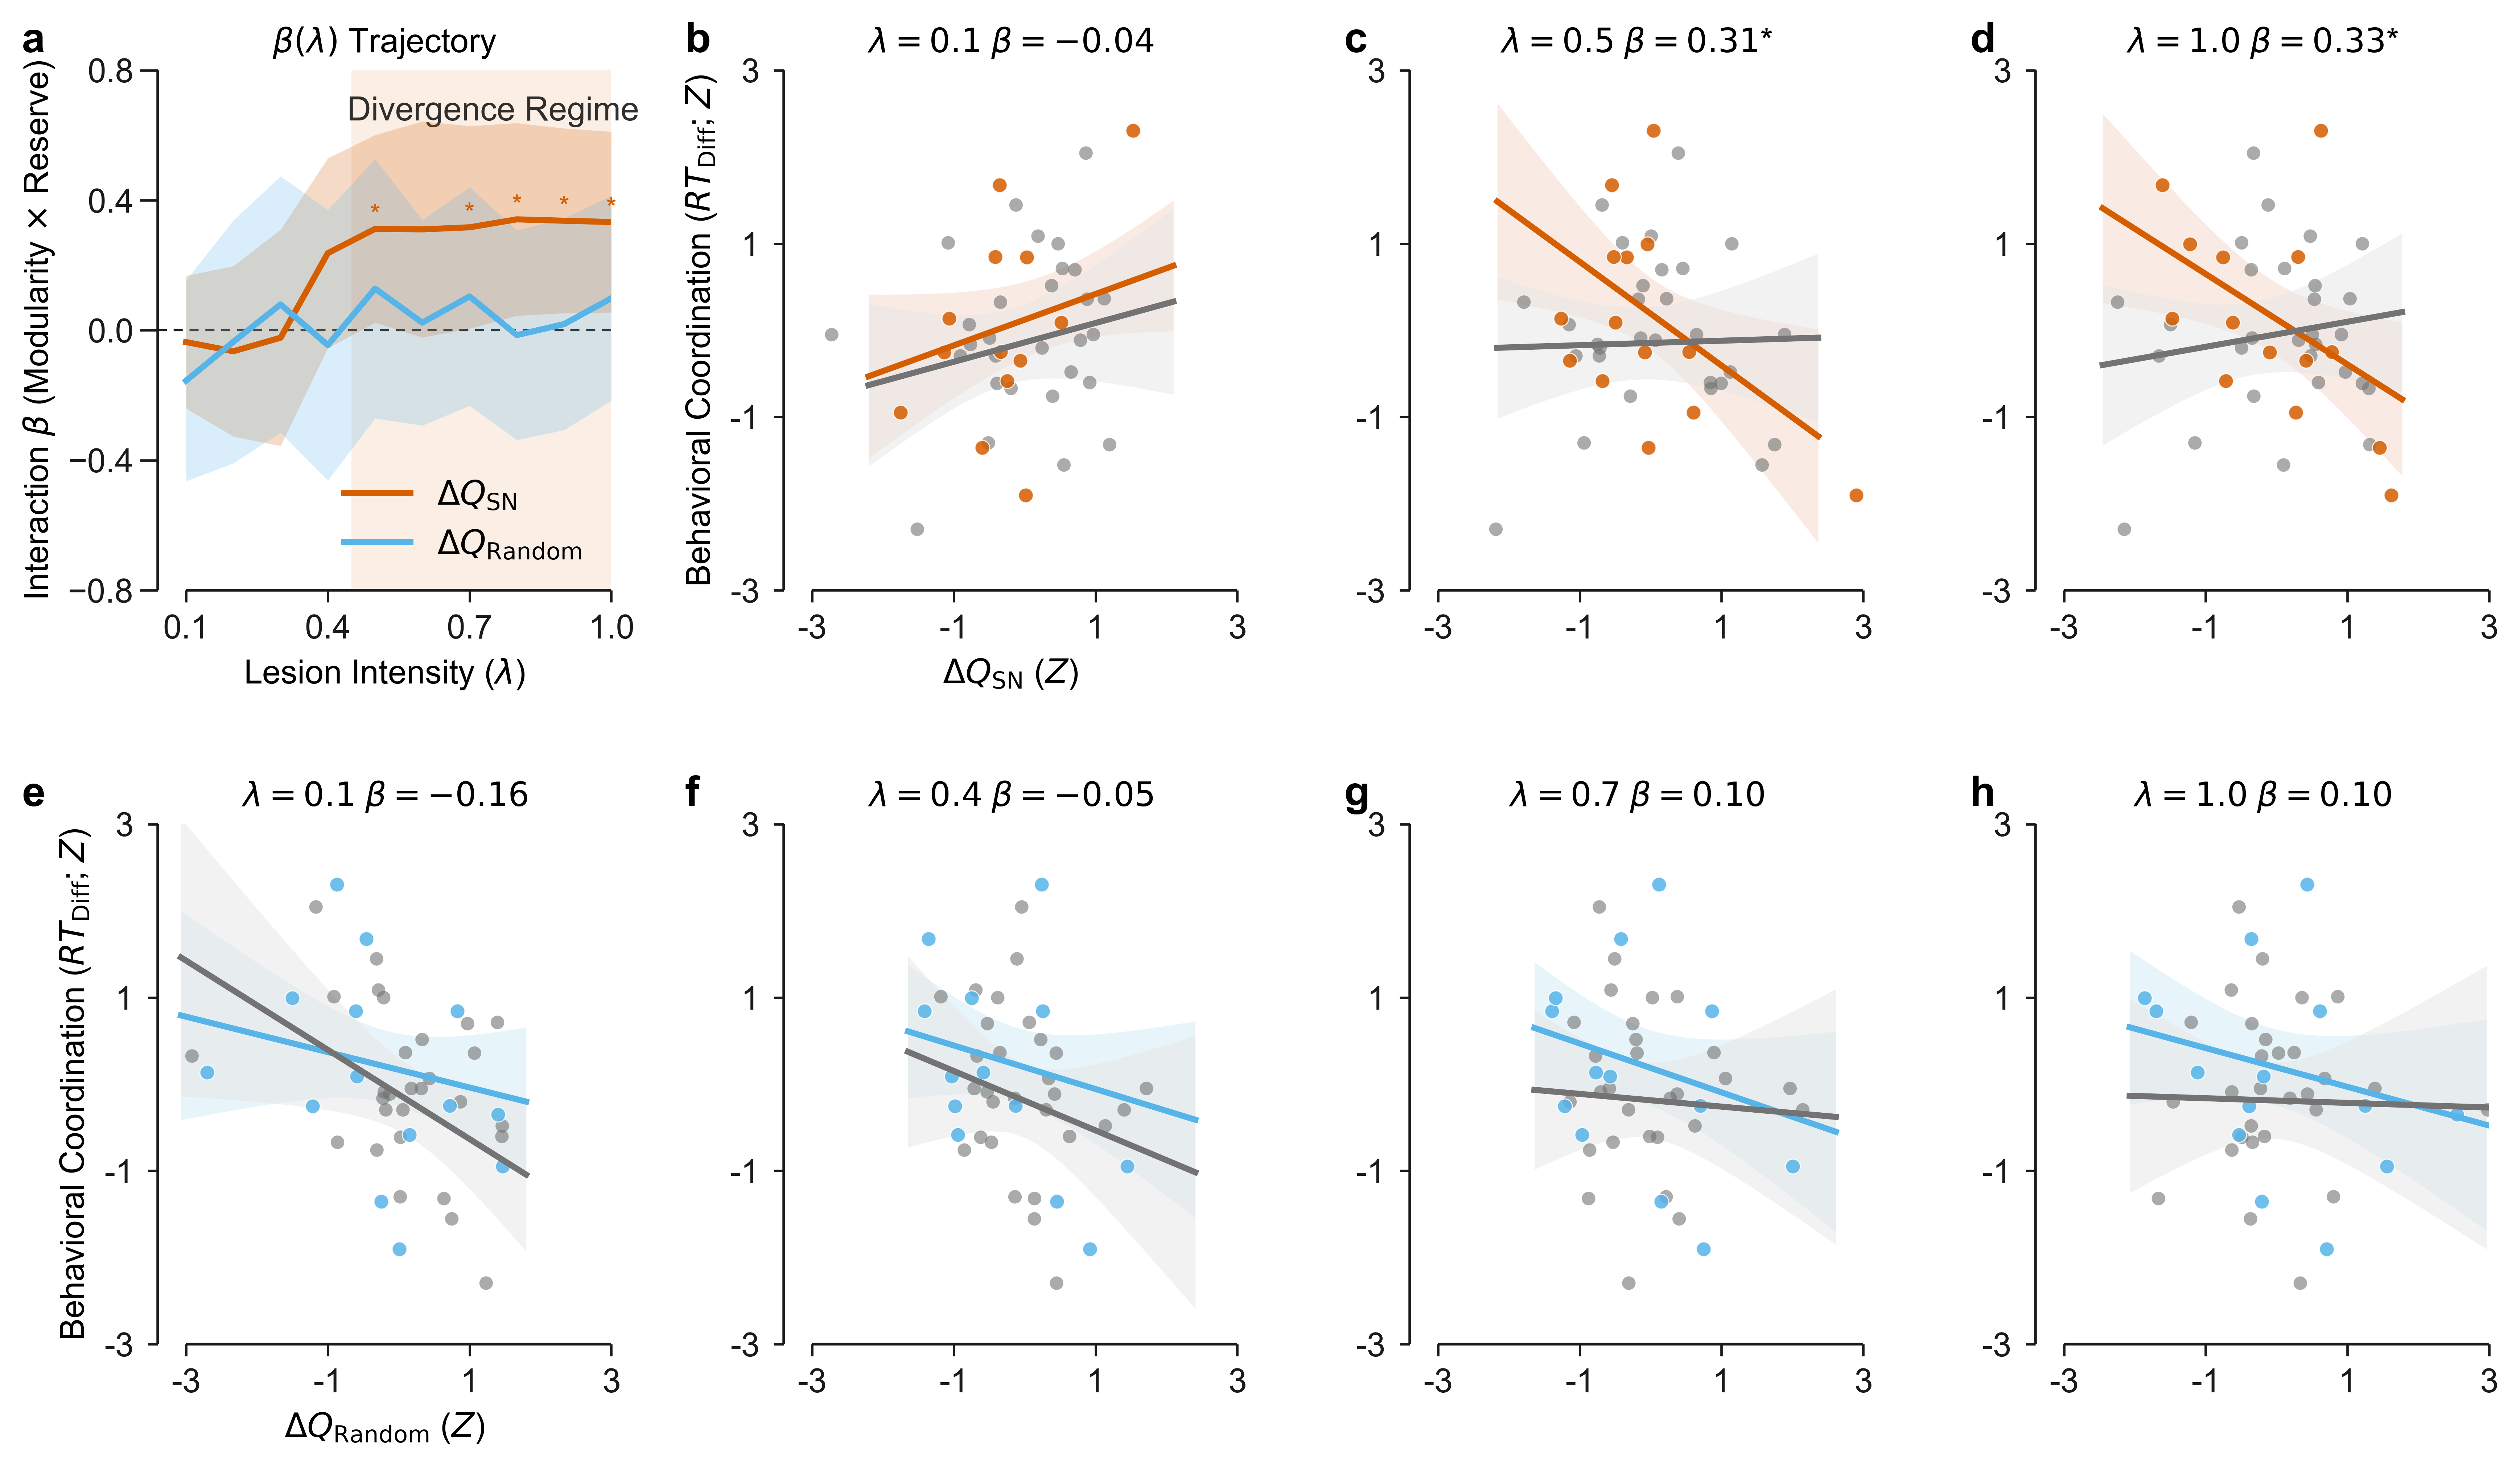

In [4]:
def _conditional_line_band(
    xg: np.ndarray, w_fix: float, model, alpha: float = 0.95
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    params = np.asarray(model.params, dtype=float)
    cov = np.asarray(model.cov_params(), dtype=float)
    tc = float(scipy_stats.t.ppf(0.5 + alpha / 2, model.df_resid))
    yhat = np.empty_like(xg)
    lo = np.empty_like(xg)
    hi = np.empty_like(xg)
    for i, xv in enumerate(xg):
        grad = np.array([1.0, xv, w_fix, xv * w_fix])
        pred = float(grad @ params)
        se = float(np.sqrt(grad @ cov @ grad))
        yhat[i] = pred
        lo[i] = pred - tc * se
        hi[i] = pred + tc * se
    return yhat, lo, hi


def _sig_stars(p: float) -> str:
    if not np.isfinite(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def _traj_x_shift(ax: plt.Axes, x_min: float, y_min: float) -> float:
    ax.figure.canvas.draw()
    p0 = ax.transData.transform((x_min, y_min))
    scale = ax.figure.dpi / 72.0
    gx, _ = ax.transData.inverted().transform((p0[0] + INTERACT_X_SHIFT_PT * scale, p0[1]))
    return float(gx - x_min)


def _traj_tick_len_data(ax: plt.Axes, x_min: float, y_min: float) -> float:
    p0 = ax.transData.transform((x_min, y_min))
    p1 = (p0[0], p0[1] - INTERACT_TICK_LEN_PT * ax.figure.dpi / 72.0)
    _, y1 = ax.transData.inverted().transform(p1)
    return float(y_min - y1)


def _traj_draw_disconnected_axes(
    ax: plt.Axes, xmin: float, xmax: float, ymin: float, ymax: float, x_shift: float
) -> None:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(
        axis="both", top=False, right=False, bottom=True, left=True,
        direction="out", length=0, width=0.8, colors=TEXT, pad=8,
    )
    kw = dict(color=TEXT, lw=0.9, clip_on=False, zorder=6, solid_capstyle="butt")
    ax.plot([xmin, xmin], [ymin, ymax], **kw)
    ax.plot([xmin + x_shift, xmax + x_shift], [ymin, ymin], **kw)


def _traj_outward_tick_marks(ax: plt.Axes, xmin: float, ymin: float) -> None:
    tl = _traj_tick_len_data(ax, xmin, ymin)
    tk = dict(color=TEXT, lw=0.8, clip_on=False, zorder=8, solid_capstyle="butt")
    for x in ax.get_xticks():
        ax.plot([x, x], [ymin, ymin - tl], **tk)
    for y in ax.get_yticks():
        ax.plot([xmin - tl, xmin], [y, y], **tk)


def plot_interaction_beta_trajectory(
    model_random: pd.DataFrame,
    model_sn: pd.DataFrame,
    *,
    ax: plt.Axes | None = None,
    title: str | None = None,
    lambda_min: float = LAMBDA_MIN_PLOT,
) -> plt.Axes:
    """Plot interaction beta trajectory with confidence bands."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6.2, 4.0), dpi=DPI)
    axis_x_min = TRAJ_X_MIN
    axis_x_max = TRAJ_X_MAX
    y_min, y_max = -0.8, 0.8
    axis_ticks = np.arange(axis_x_min, axis_x_max + 1e-9, TRAJ_X_TICK_STEP)
    ax.set_xlim(axis_x_min, axis_x_max)
    ax.set_ylim(y_min, y_max)
    ax.figure.canvas.draw()
    x_shift = _traj_x_shift(ax, axis_x_min, y_min)
    div_lo, div_hi = infer_divergence_regime(model_sn, model_random, lambda_min=lambda_min)
    ax.axvspan(
        div_lo - 0.05 + x_shift, div_hi + 0.02 + x_shift,
        color=SN_RED, alpha=0.10, zorder=0, linewidth=0,
    )
    ax.text(
        (div_lo + div_hi) / 2 + x_shift, 0.72, "Divergence Regime",
        ha="center", va="top", fontsize=FS, color=TEXT, alpha=0.9, zorder=1,
    )
    for traj, color, label in [
        (model_sn, SN_RED, "$\\Delta Q_{\\mathrm{SN}}$"),
        (model_random, BLUE, "$\\Delta Q_{\\mathrm{Random}}$"),
    ]:
        sub = traj[traj["lesion_lambda"] >= lambda_min - 1e-9].copy()
        valid = sub["b3"].notna() & sub["ci_lo"].notna() & sub["ci_hi"].notna()
        x = sub.loc[valid, "lesion_lambda"].values + x_shift
        y = sub.loc[valid, "b3"].values
        ylo = sub.loc[valid, "ci_lo"].values
        yhi = sub.loc[valid, "ci_hi"].values
        ax.fill_between(x, ylo, yhi, color=color, alpha=0.22, linewidth=0, zorder=3)
        ax.plot(x, y, "-", color=color, lw=2.0, label=label, zorder=4)
        for xi, yi, pi in zip(x, y, sub.loc[valid, "p_b3"].values, strict=False):
            stars = _sig_stars(pi)
            if stars:
                ax.text(xi, yi, stars, ha="center", va="bottom", fontsize=FS - 2, color=color, zorder=6)
    ax.axhline(0, color=TEXT, ls=(0, (4, 3)), lw=0.75, zorder=1)
    ax.set_xlabel("Lesion Intensity ($\\lambda$)")
    ax.set_ylabel("Interaction $\\beta$ (Modularity $\\times$ Reserve)")
    ax.set_xticks([t + x_shift for t in axis_ticks])
    ax.set_xticklabels([f"{t:.1f}" for t in axis_ticks])
    ax.set_yticks(np.arange(y_min, y_max + 1e-9, 0.4))
    ax.set_xlim(axis_x_min, axis_x_max + x_shift)
    ax.set_ylim(y_min, y_max)
    _traj_draw_disconnected_axes(ax, axis_x_min, axis_x_max, y_min, y_max, x_shift)
    _traj_outward_tick_marks(ax, axis_x_min, y_min)
    ax.legend(frameon=False, loc="lower right")
    ax.set_title(title or "$\\beta(\\lambda)$ Trajectory", fontsize=FS)
    return ax


def _interact_x_shift(ax: plt.Axes) -> float:
    x_min = -INTERACT_AXIS_LIM
    y_min = -INTERACT_AXIS_LIM
    ax.figure.canvas.draw()
    p0 = ax.transData.transform((x_min, y_min))
    scale = ax.figure.dpi / 72.0
    gx, _ = ax.transData.inverted().transform((p0[0] + INTERACT_X_SHIFT_PT * scale, p0[1]))
    return float(gx - x_min)


def _interact_tick_len_data(ax: plt.Axes) -> float:
    x_min = -INTERACT_AXIS_LIM
    y_min = -INTERACT_AXIS_LIM
    p0 = ax.transData.transform((x_min, y_min))
    p1 = (p0[0], p0[1] - INTERACT_TICK_LEN_PT * ax.figure.dpi / 72.0)
    _, y1 = ax.transData.inverted().transform(p1)
    return float(y_min - y1)


def _interact_draw_disconnected_axes(ax: plt.Axes, x_shift: float) -> None:
    xmin = -INTERACT_AXIS_LIM
    xmax = INTERACT_AXIS_LIM
    ymin, ymax = -INTERACT_AXIS_LIM, INTERACT_AXIS_LIM
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(
        axis="both", top=False, right=False, bottom=True, left=True,
        direction="out", length=0, width=0.8, colors=TEXT, pad=8,
    )
    kw = dict(color=TEXT, lw=0.9, clip_on=False, zorder=6, solid_capstyle="butt")
    ax.plot([xmin, xmin], [ymin, ymax], **kw)
    ax.plot([xmin + x_shift, xmax + x_shift], [ymin, ymin], **kw)


def _interact_outward_tick_marks(ax: plt.Axes) -> None:
    xmin = -INTERACT_AXIS_LIM
    ymin = -INTERACT_AXIS_LIM
    tl = _interact_tick_len_data(ax)
    tk = dict(color=TEXT, lw=0.8, clip_on=False, zorder=8, solid_capstyle="butt")
    for x in ax.get_xticks():
        ax.plot([x, x], [ymin, ymin - tl], **tk)
    for y in ax.get_yticks():
        ax.plot([xmin - tl, xmin], [y, y], **tk)


def plot_interaction_panel(
    fit: dict,
    x_col: str,
    *,
    lam: float,
    ax: plt.Axes,
    x_label: str,
    show_axis_labels: bool = True,
    accent_color: str = CD_GREEN,
    accent_light: str = CD_GREEN_LIGHT,
) -> None:
    sub = fit["sub_z"]
    model = fit["model"]
    x = sub[x_col].values
    w = sub[RESERVE_COL].values
    y = sub[COUPLING_COL].values
    hi = w <= -0.5
    axis_lim = INTERACT_AXIS_LIM
    ax.set_xlim(-axis_lim, axis_lim)
    ax.set_ylim(-axis_lim, axis_lim)
    ax.figure.canvas.draw()
    x_shift = _interact_x_shift(ax)
    x_min, x_max = np.percentile(x, [2, 98])
    pad = 0.08 * (x_max - x_min + 1e-9)
    x_min -= pad
    x_max += pad
    xg = np.linspace(x_min, x_max, 120)
    xg_plot = xg + x_shift
    for w_fix, line_c, band_c in [(-1.0, accent_color, accent_light), (1.0, NET_GRAY, GRAY_LIGHT)]:
        yhat, ylo, yhi = _conditional_line_band(xg, w_fix, model)
        ax.fill_between(xg_plot, ylo, yhi, color=band_c, alpha=0.55, linewidth=0, zorder=1)
        ax.plot(xg_plot, yhat, color=line_c, lw=2.0, zorder=4)
    ax.scatter(x[~hi] + x_shift, y[~hi], s=20, c=NET_GRAY, alpha=0.6, edgecolors="none", zorder=2)
    ax.scatter(
        x[hi] + x_shift, y[hi], s=24, c=accent_color, alpha=0.85,
        edgecolors="white", linewidths=0.35, zorder=3,
    )
    b3 = float(model.params[3])
    p3 = float(model.pvalues[3])
    ax.set_title(f"$\\lambda={lam:.1f}$ $\\beta={b3:.2f}${_sig_stars(p3)}", fontsize=FS)
    ax.set_xlabel(x_label if show_axis_labels else "")
    ax.set_ylabel(Y_LABEL_INTERACT if show_axis_labels else "")
    axis_ticks = np.arange(-axis_lim, axis_lim + 1e-9, INTERACT_AXIS_TICK_STEP)
    ax.set_xticks([t + x_shift for t in axis_ticks])
    ax.set_xticklabels([f"{t:.0f}" for t in axis_ticks])
    ax.set_yticks(axis_ticks)
    ax.set_yticklabels([f"{t:.0f}" for t in axis_ticks])
    ax.set_xlim(-axis_lim, axis_lim + x_shift)
    ax.set_ylim(-axis_lim, axis_lim)
    _interact_draw_disconnected_axes(ax, x_shift)
    _interact_outward_tick_marks(ax)


def _panel_label_x_left(fig: plt.Figure, ax: plt.Axes, renderer) -> float:
    ylab_bb = ax.yaxis.label.get_window_extent(renderer)
    x_left, _ = fig.transFigure.inverted().transform((ylab_bb.x0, ylab_bb.y0))
    return float(x_left)


def _place_panel_labels(
    fig: plt.Figure,
    top_row: list[tuple[plt.Axes, str]],
    bottom_row: list[tuple[plt.Axes, str]],
) -> None:
    """Place lowercase panel letters aligned with each column."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    col_x_left = [_panel_label_x_left(fig, ax, renderer) for ax, _ in top_row]
    for col_idx, (ax, letter) in enumerate(top_row):
        ax_bb = ax.get_window_extent(renderer)
        _, y_top = fig.transFigure.inverted().transform((ax_bb.x0, ax_bb.y1))
        fig.text(
            col_x_left[col_idx], y_top + 0.006, letter,
            ha="left", va="bottom", fontsize=FS + 3, fontweight="bold",
        )
    for col_idx, (ax, letter) in enumerate(bottom_row):
        ax_bb = ax.get_window_extent(renderer)
        _, y_top = fig.transFigure.inverted().transform((ax_bb.x0, ax_bb.y1))
        fig.text(
            col_x_left[col_idx], y_top + 0.006, letter,
            ha="left", va="bottom", fontsize=FS + 3, fontweight="bold",
        )


def _apply_transparent_background(fig: plt.Figure) -> None:
    fig.patch.set_alpha(0)
    for ax in fig.get_axes():
        ax.patch.set_alpha(0)


def build_gradual_lesion_figure(
    merged_sn_df: pd.DataFrame,
    merged_null_df: pd.DataFrame,
    model_random_df: pd.DataFrame,
    model_sn_df: pd.DataFrame,
    deltaq_lambdas: list[float] | None = None,
    null_lambdas: list[float] | None = None,
) -> plt.Figure:
    deltaq_lambdas = deltaq_lambdas or DELTAQ_LAMBDAS
    null_lambdas = null_lambdas or NULL_LAMBDAS
    n_cols = max(len(deltaq_lambdas), len(null_lambdas))
    fig = plt.figure(figsize=(PANEL_WIDTH * n_cols, 7.6), dpi=DPI, facecolor="none")
    gs = fig.add_gridspec(
        2, n_cols,
        width_ratios=[1.0] * n_cols,
        height_ratios=[1.0, 1.0],
        hspace=0.45,
        wspace=0.38,
    )
    ax_traj = fig.add_subplot(gs[0, 0])
    plot_interaction_beta_trajectory(
        model_random_df, model_sn_df, ax=ax_traj, lambda_min=LAMBDA_MIN_PLOT,
    )
    x_label_sn = r"$\Delta Q_{\mathrm{SN}}$ ($Z$)"
    sn_axes: list[plt.Axes] = []
    for col, lam in enumerate(deltaq_lambdas, start=1):
        ax = fig.add_subplot(gs[0, col])
        sn_axes.append(ax)
        fit = fit_moderation_at_lambda(merged_sn_df, lam, X_COL_MODEL_B)
        if fit is None:
            ax.text(0.5, 0.5, f"$\\lambda={lam:.1f}$\ninsufficient n", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue
        plot_interaction_panel(
            fit, X_COL_MODEL_B, lam=lam, ax=ax, x_label=x_label_sn,
            show_axis_labels=(col == 1), accent_color=SN_RED, accent_light=SN_RED_LIGHT,
        )
    x_label_random = r"$\Delta Q_{\mathrm{Random}}$ ($Z$)"
    null_axes: list[plt.Axes] = []
    for col, lam in enumerate(null_lambdas):
        ax = fig.add_subplot(gs[1, col])
        null_axes.append(ax)
        fit = fit_moderation_at_lambda(merged_null_df, lam, X_COL_MODEL_RANDOM)
        if fit is None:
            ax.text(0.5, 0.5, f"$\\lambda={lam:.1f}$\ninsufficient n", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue
        plot_interaction_panel(
            fit, X_COL_MODEL_RANDOM, lam=lam, ax=ax, x_label=x_label_random,
            show_axis_labels=(col == 0), accent_color=BLUE, accent_light=BLUE_LIGHT,
        )
    fig.tight_layout()
    _place_panel_labels(
        fig,
        top_row=[(ax_traj, "a")] + list(zip(sn_axes, "bcd", strict=False)),
        bottom_row=list(zip(null_axes, "efgh", strict=False)),
    )
    _apply_transparent_background(fig)
    return fig


fig = build_gradual_lesion_figure(merged_df, merged_null_df, model_random_df, model_b_df)
plt.show()


In [5]:
FIG_STEM = "gradual_lesion_moderation_figure"
SAVE_KW = dict(bbox_inches="tight", transparent=True, facecolor="none", edgecolor="none")

model_b_df.to_csv(RESULTS_DIR / "gradual_lesion_model_b_by_lambda.csv", index=False)
model_random_df.to_csv(RESULTS_DIR / "gradual_lesion_model_random_by_lambda.csv", index=False)
beta_traj_df.to_csv(RESULTS_DIR / "gradual_lesion_beta_trajectory.csv", index=False)
merged_df.to_csv(RESULTS_DIR / "gradual_lesion_merged_analysis.csv", index=False)
merged_null_df.to_csv(RESULTS_DIR / "gradual_lesion_merged_null_analysis.csv", index=False)

for ext, extra in [
    ("png", {"dpi": DPI}),
    ("pdf", {}),
    ("svg", {}),
    ("eps", {"format": "eps"}),
]:
    fig.savefig(FIGURES_DIR / f"{FIG_STEM}.{ext}", **SAVE_KW, **extra)

print("Saved CSV summaries to:", RESULTS_DIR.resolve())
print("Saved figures to:", FIGURES_DIR.resolve())
print(f"Figure exports: {FIG_STEM}.png / .pdf / .svg / .eps @ {DPI} DPI (transparent)")


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved CSV summaries to: D:\文件同步\文件\数据分析结果\data_code_figure\gradual_virtual_lesion\results
Saved figures to: D:\文件同步\文件\数据分析结果\data_code_figure\gradual_virtual_lesion\figures
Figure exports: gradual_lesion_moderation_figure.png / .pdf / .svg / .eps @ 600 DPI (transparent)
